# Heston Model

**What this is:** Heston (1993) replaces the constant volatility of Black-Scholes with a
variance that follows its own mean reverting square root (CIR) process, correlated with
the price through $\rho$.

**Why it matters:** That correlation is what generates a volatility skew, since a
negative $\rho$ makes large downward moves coincide with rising volatility, which is what
is observed in equity index options. It is probably the most widely used stochastic
volatility model in practice, largely due to its characteristic function being known in
closed form, which means European options can be priced by Fourier inversion rather than
by simulation.

## Setup

In [1]:
import sys, pathlib

# Walk up to the repository root (the directory containing `src/`) so this
# notebook imports the same way regardless of how deeply it is nested.
REPO_ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src").is_dir())
sys.path.append(str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from src.models import simulate_heston
plt.style.use("seaborn-v0_8")

## Parameters

| Symbol | Code | Meaning |
|---|---|---|
| $S_0$ | `S0` | initial asset price |
| $v_0$ | `v0` | initial variance, set to $\theta$ in this notebook |
| $\mu$ | `mu` | drift of the price process |
| $\kappa$ | `kappa` | mean reversion speed of the variance |
| $\theta$ | `theta` | long run variance level |
| $\xi$ | `xi` | volatility of volatility |
| $\rho$ | `rho` | correlation between the price and variance shocks |
| $T$ | `T` | time horizon in years |
| $n$ | `n` | number of time steps (252 trading days) |
| $\Delta t$ | `dt` | time step size, $\Delta t = T/n$ |
| $\varepsilon^{S}_{i,j},\ \varepsilon^{v}_{i,j}$ | `epsilon_S`, `epsilon_v` | correlated standard normal shocks driving $W^{S}$ and $W^{v}$ |

Note that $\theta$, $v_0$ and $\xi$ are quoted in variance units rather than
volatility units, so a $\theta$ of $0.05$ corresponds to a long run volatility of
roughly $22\%$.

In [2]:
num_paths = 100
n = 252
rho = -0.7
T = 1
dt = T / n
theta = 0.05
kappa = 6
xi = 0.4
mu = 0.03
S0 = 100

## Model

**Continuous time:**

$$dS_t = \mu S_t \, dt + \sqrt{v_t} \, S_t \, dW^{S}_t$$

$$dv_t = \kappa \left( \theta - v_t \right) dt + \xi \sqrt{v_t} \, dW^{v}_t,
\qquad d\langle W^{S}, W^{v} \rangle_t = \rho \, dt$$

The variance follows a Cox-Ingersoll-Ross process, which stays positive in continuous
time provided the Feller condition $2 \kappa \theta \ge \xi^2$ holds.

**Correlated shocks:** two independent standard normals are combined so that the pair has
correlation $\rho$,

$$\varepsilon^{v}_{i,j} = \rho \, \varepsilon^{S}_{i,j} + \sqrt{1 - \rho^2} \, Z_{i,j},
\qquad \varepsilon^{S}_{i,j}, Z_{i,j} \sim \mathcal{N}(0,1)$$

**Euler-Maruyama discretisation:** a discretised CIR process can still go negative even
when the Feller condition holds, so the variance is truncated at zero wherever it is used.
Writing $x^{+} = \max(x, 0)$, this is the full truncation scheme:

$$v_{i+1,j} = v_{i,j} + \kappa \left( \theta - v^{+}_{i,j} \right) \Delta t
+ \xi \sqrt{v^{+}_{i,j}} \sqrt{\Delta t} \, \varepsilon^{v}_{i,j}$$

$$S_{i+1,j} = S_{i,j} + \mu S_{i,j} \Delta t
+ \sqrt{v^{+}_{i,j}} \, S_{i,j} \sqrt{\Delta t} \, \varepsilon^{S}_{i,j}$$

where $i$ indexes time and $j$ indexes paths, with $i \in [0, n-1]$ and $j \in [1, \texttt{num\_paths}]$.

**In code:** both loops live in `src/models.py`, as `simulate_cir_variance` for the
variance and `simulate_heston` for the price, with the correlated shocks produced by
`generate_correlated_normals`. The truncation $v^{+}$ is `np.maximum(v[i], 0)` and both
arrays are stored as `(n + 1, num_paths)`, matching the $(i, j)$ ordering used above.

In [3]:
S, v = simulate_heston(S0=S0, v0=theta, n=n, dt=dt, kappa=kappa, theta=theta, xi=xi, rho=rho, mu=mu, num_paths=num_paths)

## Results

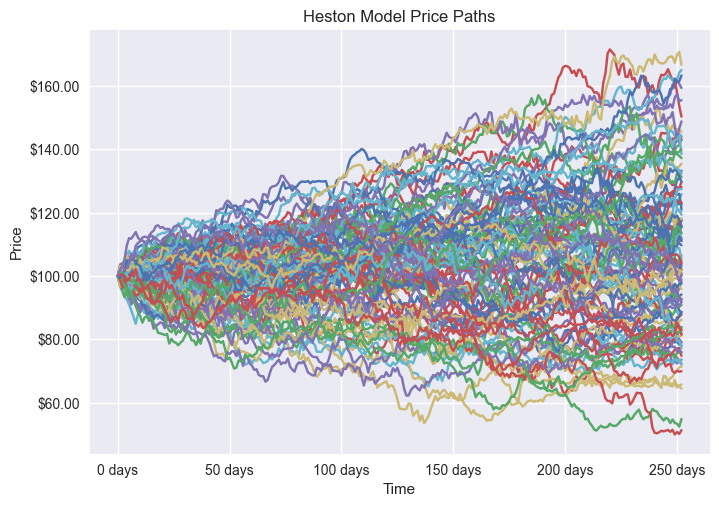

In [4]:
plt.plot(S)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Heston Model Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.gca().xaxis.set_major_formatter("{x:,.0f} days")
plt.show()